In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv(r"C:\Users\hi\Desktop\Project 4.2\student_dropout_dataset.csv")
df.head()

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_name
0,STU00001,26,Alexandria,2024-01-13,0,3,5,0.3571,5.29,10,5,0.1064,0,0,active
1,STU00002,23,Amman,2024-05-05,0,6,0,0.0000,0.84,7,0,0.6627,1,2,dropped
2,STU00003,17,Dubai,2024-03-12,0,3,1,0.0435,1.79,36,0,0.7299,1,2,dropped
3,STU00004,23,Alexandria,2024-12-12,0,6,13,0.4396,0.78,9,0,0.5315,1,1,at-risk
4,STU00005,20,Baghdad,2024-02-14,0,5,5,0.2078,0.92,11,0,0.7904,1,2,dropped


In [44]:
df.isna().sum()

student_id                0
age                       0
region                    0
enroll_date               0
exam_season               0
courses_enrolled          0
completed_assignments     0
completion_rate           0
login_frequency           0
last_activity_days_ago    0
forum_posts_count         0
dropout_score             0
label                     0
label_multiclass          0
label_name                0
dtype: int64

# no null values

## EXPLORATORY DATA ANALYSIS

In [45]:
df.label_name.nunique()

3

In [46]:
df['enroll_date'] = pd.to_datetime(df.enroll_date)

df['day'] = df.enroll_date.dt.day
df['year'] = df.enroll_date.dt.year
df['month'] = df.enroll_date.dt.month_name()
df.head()

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_name,day,year,month
0,STU00001,26,Alexandria,2024-01-13,0,3,5,0.3571,5.29,10,5,0.1064,0,0,active,13,2024,January
1,STU00002,23,Amman,2024-05-05,0,6,0,0.0000,0.84,7,0,0.6627,1,2,dropped,5,2024,May
2,STU00003,17,Dubai,2024-03-12,0,3,1,0.0435,1.79,36,0,0.7299,1,2,dropped,12,2024,March
3,STU00004,23,Alexandria,2024-12-12,0,6,13,0.4396,0.78,9,0,0.5315,1,1,at-risk,12,2024,December
4,STU00005,20,Baghdad,2024-02-14,0,5,5,0.2078,0.92,11,0,0.7904,1,2,dropped,14,2024,February


In [47]:
# CREATING A LIST OF CATEGORIC COLUMNS
cat_col = []
for col in df.columns:
    if df[col].nunique() <=15:
        cat_col.append(col)

cat_col

['region',
 'exam_season',
 'courses_enrolled',
 'label',
 'label_multiclass',
 'label_name',
 'year',
 'month']

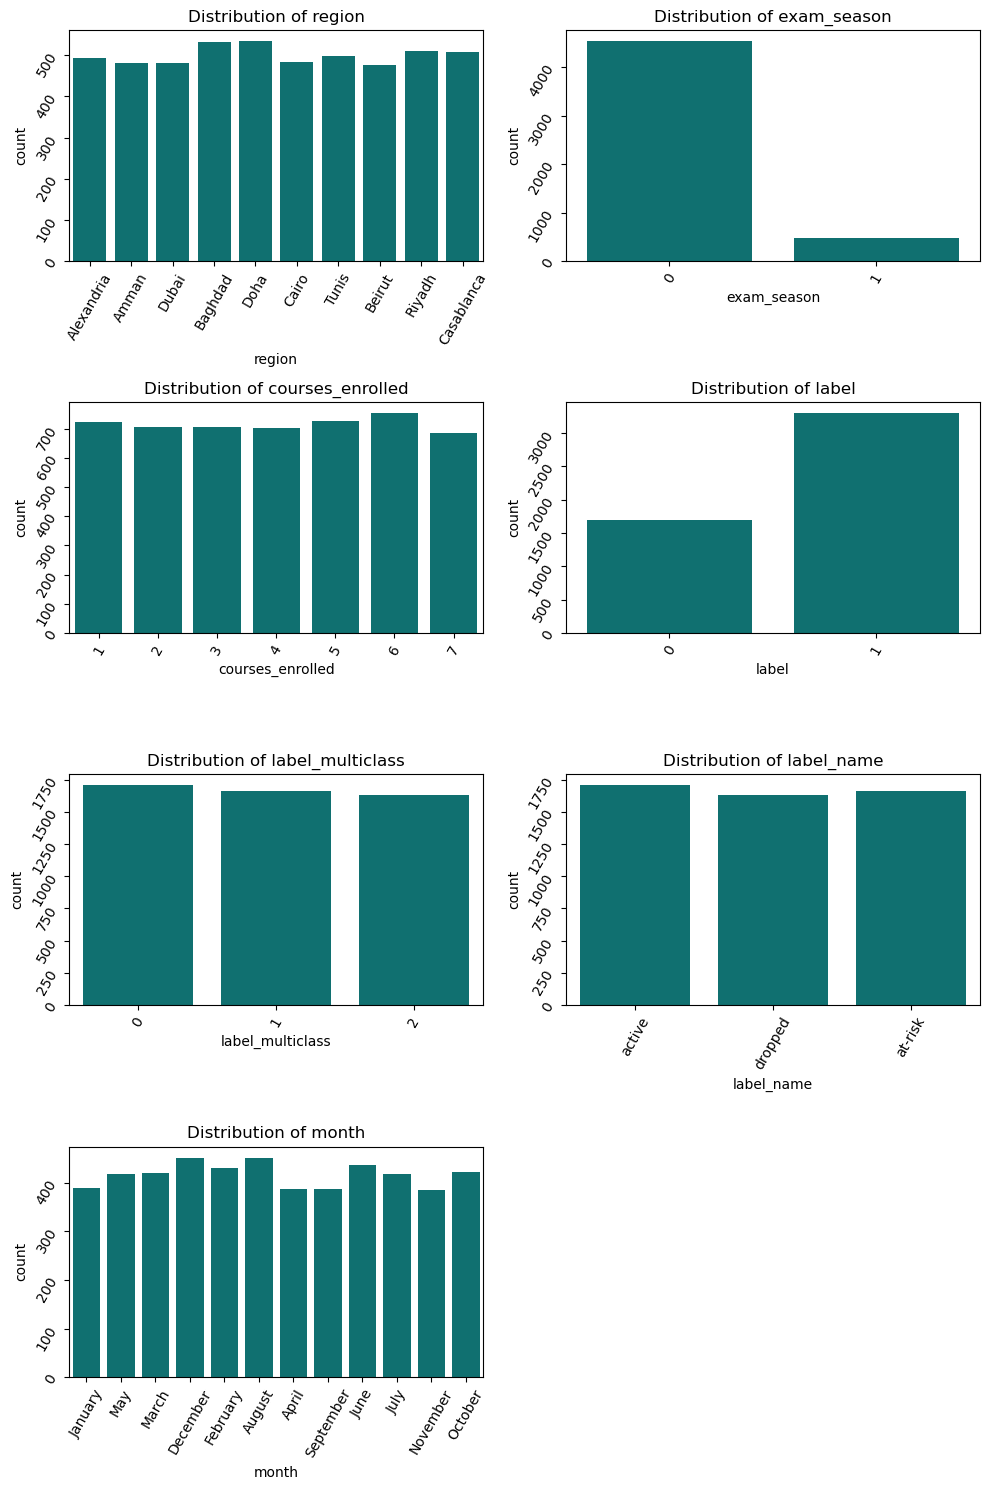

In [48]:
#VISUALIZING CATEGORIC COLUMNS
# USED LOOPING TO PERFORM SEVERAL COLUMN PLOTTING AT ONCE
fig, ax = plt.subplots(4,2, figsize=(10,15))
ax=ax.flatten()
cat_col = ['region',
 'exam_season',
 'courses_enrolled',
 'label',
 'label_multiclass',
 'label_name',
 'month']
for i, col in enumerate(cat_col):
    sns.countplot(data=df, x=col, color='teal', ax=ax[i]),
    ax[i].set_xlabel(f'{col}'),
    ax[i].set_title(f'Distribution of {col}'),
    ax[i].tick_params(rotation=60),

for ax in ax:
    if not ax.has_data():
        ax.remove()
plt.tight_layout()
plt.savefig('Distribution of categoric features.png')
plt.show()

### Categoric columns are almost evenly distributed 
### No imbalance on the target column

In [49]:
df.drop(columns=['year','student_id'], inplace=True)

In [50]:
num_col = [col for col in df.columns if col not in cat_col]
#df['login_frequency1'] = np.log1p(df.login_frequency)
#num_col.append('login_frequency1')
num_col

['age',
 'enroll_date',
 'completed_assignments',
 'completion_rate',
 'login_frequency',
 'last_activity_days_ago',
 'forum_posts_count',
 'dropout_score',
 'day']

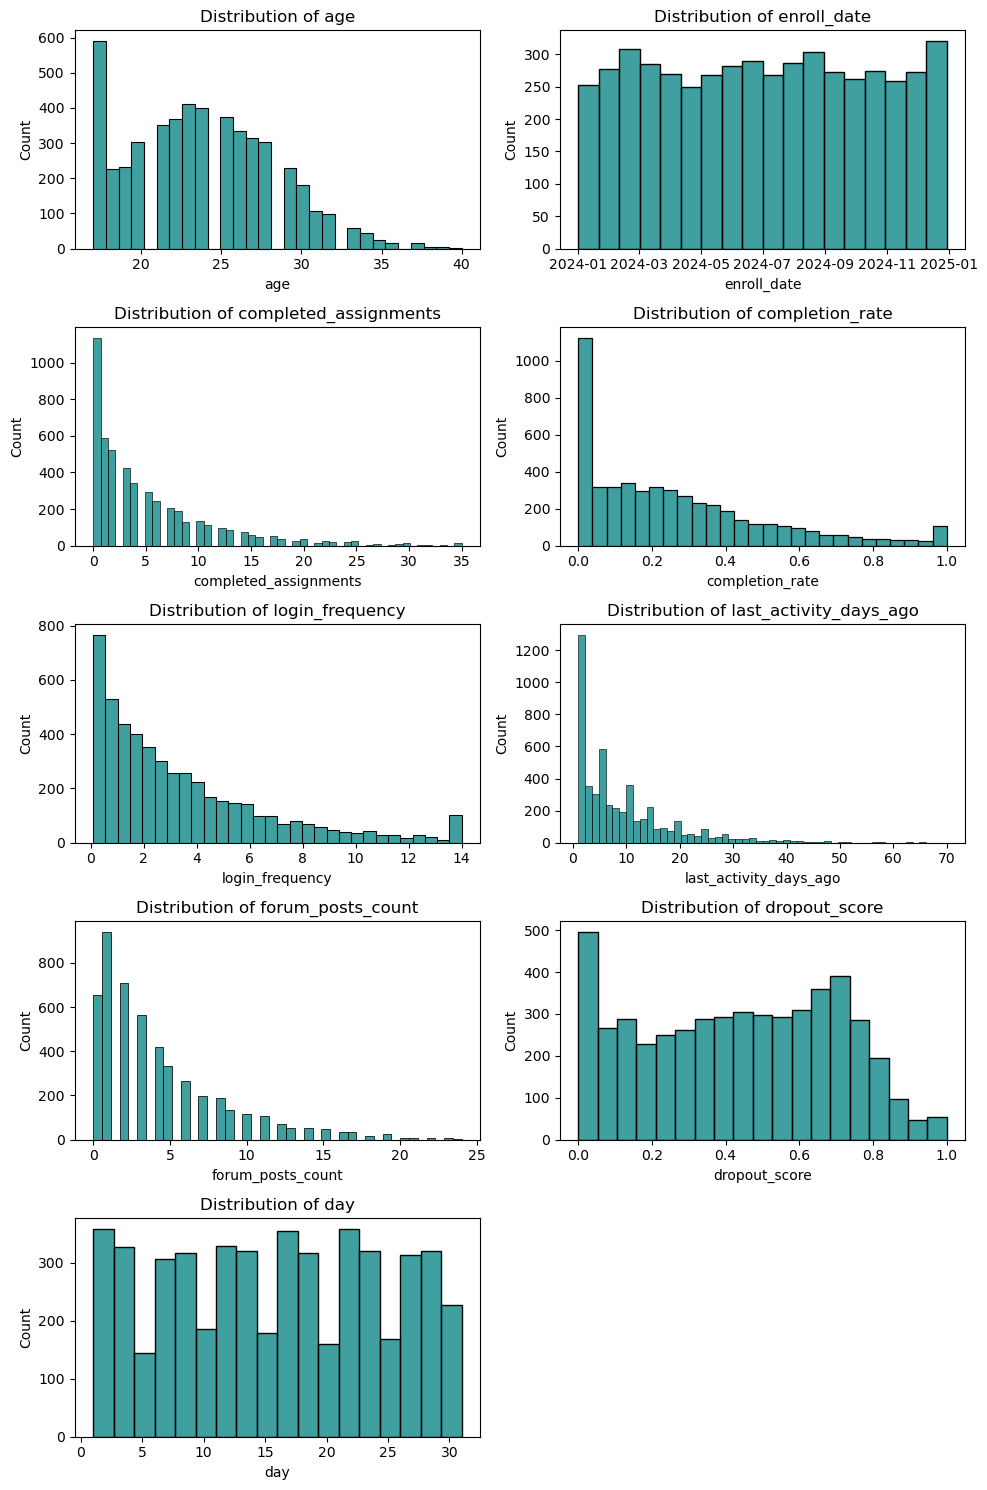

In [51]:
# Plot to visualize distribution of numeric columns

fig, ax = plt.subplots(5,2, figsize=(10,15))
ax = ax.flatten()
for i,col in enumerate(num_col):
 sns.histplot(data=df, x=col, ax=ax[i], color='teal'),
 ax[i].set_title(f'Distribution of {col}'),
 ax[i].set_xlabel(f'{col}'),

for ax in ax:
    if not ax.has_data():
        ax.remove()
plt.tight_layout()
plt.savefig('Distribution of numeric features.png')
plt.show()

# The following columns are skewed to the left
### age, completed_assignments, completion_rate, login_frequency, last_activity_days_ago and forum_post_count


# BIVARIATE ANALYSIS

In [52]:
# picking only the rows with risk to make visualization
risk_df = df[df.label_multiclass == 1]

In [53]:
#classification problem
#target is 'label_multiclass'
cat_col = ['region',
 'exam_season',
 'courses_enrolled',
 'month']

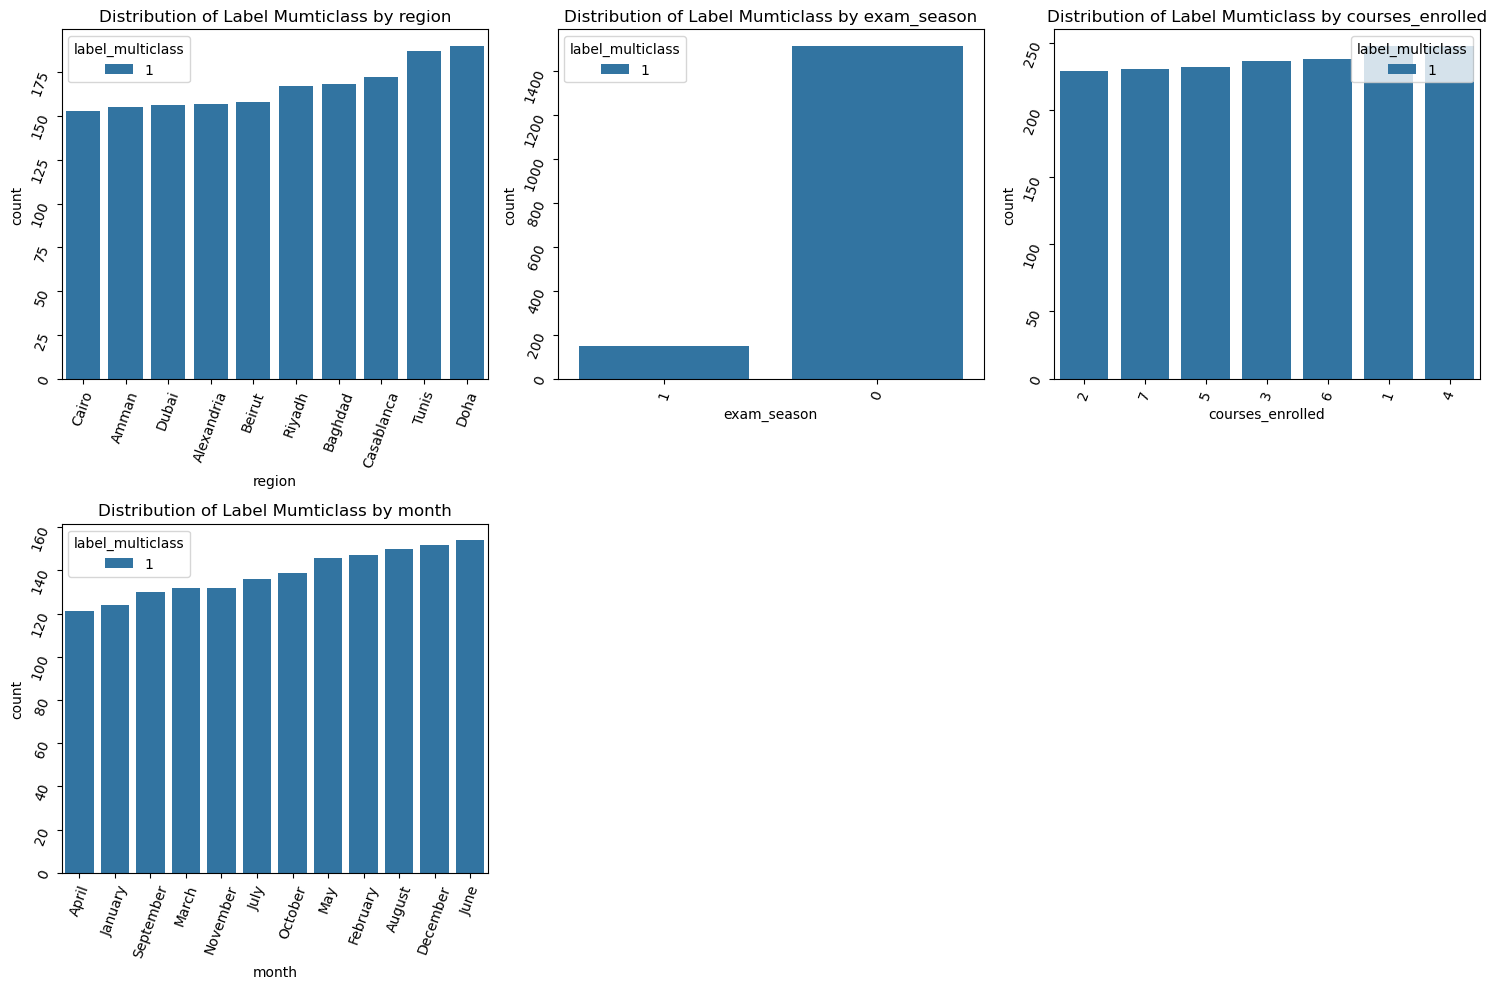

In [54]:
fig, ax=plt.subplots(2,3, figsize=(15,10))
ax=ax.flatten()
for i, col in enumerate(cat_col):
    order = risk_df.groupby(col)['label_multiclass'].sum().sort_values().index
    sns.countplot(data=risk_df,x=col,hue='label_multiclass',ax=ax[i], order=order,)
    ax[i].set_title(f'Distribution of Label Mumticlass by {col}')
    ax[i].tick_params(rotation=70)

for ax in ax:
    if not ax.has_data():
        ax.remove()

plt.tight_layout()
plt.savefig('Distribution of Students at Risk of dropping by categoric columns.png')
plt.show()

## high risk of droping if 
#### the exam season is 0
#### they are from Casablanca, Tunis and Doha
#### they enrolled on August, December or June 

In [55]:
num_col = ['age',
 'completed_assignments',
 'completion_rate',
 'login_frequency',
 'last_activity_days_ago',
 'forum_posts_count',
 'dropout_score',
 'day']

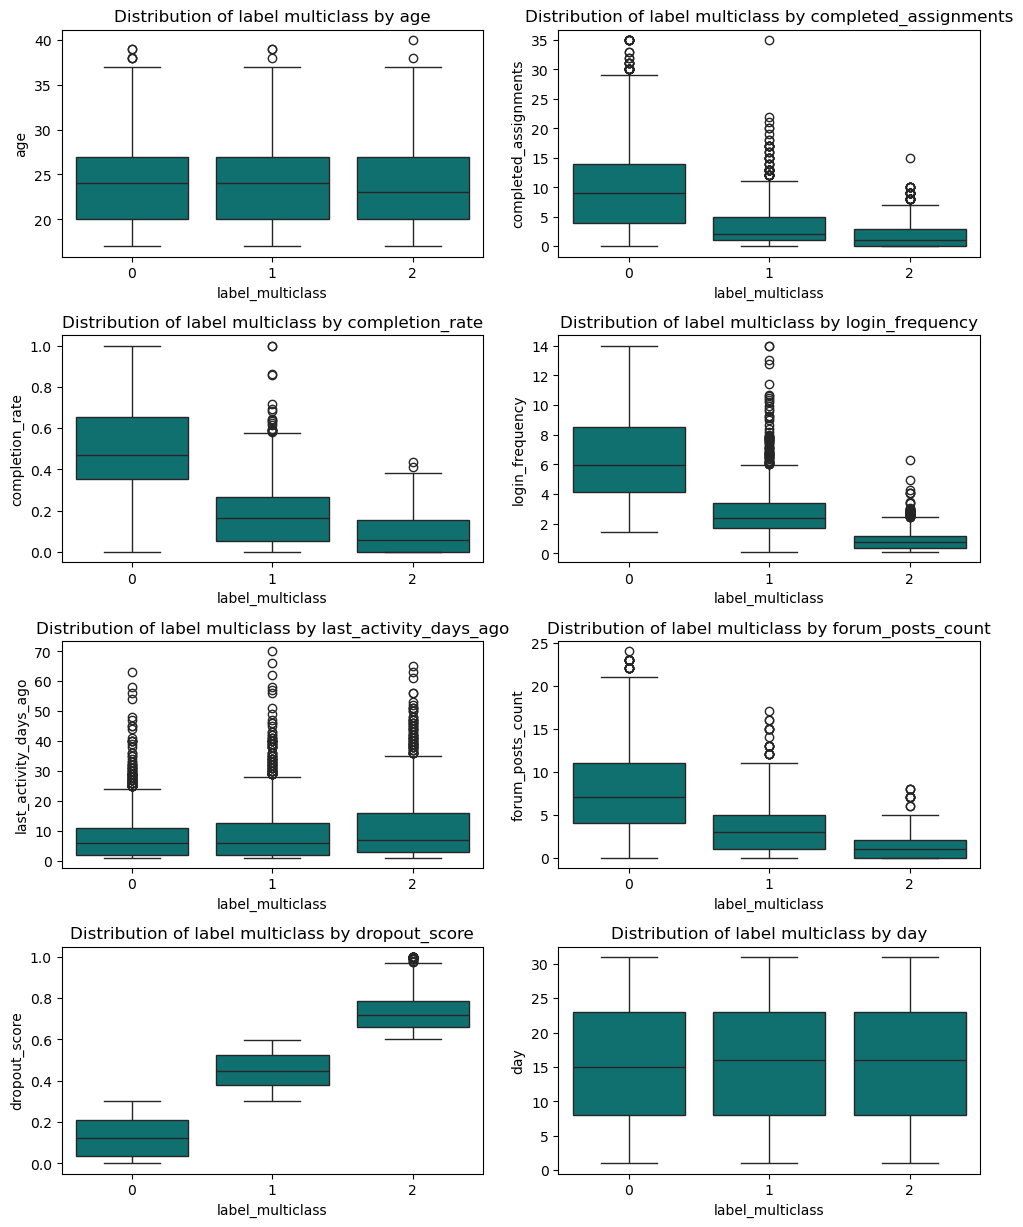

In [56]:
# creating a box plot to check on how numerical columns affect the targer column ('label_multiclass')
fig, ax=plt.subplots(5,2, figsize=(10,15))
ax = ax.flatten()
for i, col in enumerate(num_col):
    sns.boxplot(data=df,y=col, x='label_multiclass', ax=ax[i], color='teal')
    ax[i].set_title(f'Distribution of label multiclass by {col}')

for ax in ax:
    if not ax.has_data():
        ax.remove()

plt.tight_layout()
plt.savefig('Distribution of Target by Numeric Features.png')
plt.show()

### has less than 5 completed assignments
### has less than 0.2 completion rate
### has less than 4 login frequency
### has less than 5 forum post count
### has more than 0.4 in drop out score